# Hábitos de compra na Instacart

## Análise exploratória, limpeza de dados e padrões de recompra

Este projeto analisa uma amostra modificada de pedidos da Instacart para identificar padrões de horário, frequência de compra, tamanho dos pedidos e recompra de produtos.

**Objetivos principais**

- validar e limpar cinco tabelas relacionadas;
- investigar valores ausentes e duplicados sem eliminar informação válida;
- analisar quando e com que frequência os clientes compram;
- identificar produtos mais comprados, recomprados e adicionados primeiro ao carrinho;
- comunicar resultados com métricas, visualizações e limitações explícitas.

## Resumo executivo

A análise mostra que os pedidos se concentram durante o dia, com pico às **10h**. Domingo e segunda-feira são os dias com maior volume. O cliente típico realizou poucos pedidos na amostra: a mediana é de **2 pedidos por cliente**. Cada pedido possui mediana de **8 itens**, e a Banana lidera compras, recompras e itens adicionados primeiro ao carrinho.

A versão foi preparada para portfólio: utiliza caminhos relativos, nomes de variáveis claros, validações de sanidade, comparação normalizada entre dias e um ranking de recompra que considera também o volume de compras.

## 1. Configuração e carregamento dos dados

O notebook procura os arquivos na pasta `data/` do projeto e também aceita `order_products.csv.zip`. Isso evita dependência do caminho interno da plataforma TripleTen.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

COLORS = {
    "primary": "#C6153E",
    "secondary": "#2F6F9F",
    "dark": "#19181D",
    "muted": "#6E7076",
    "grid": "#D5D7DB",
}

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
def locate_project_root() -> Path:
    """Retorna a raiz do projeto quando o notebook roda da raiz ou de notebooks/."""
    current = Path.cwd().resolve()
    if current.name == "notebooks":
        return current.parent
    if (current / "notebooks").exists() or (current / "data").exists():
        return current
    return current


def locate_data_dir(project_root: Path) -> Path:
    """Localiza a pasta com os cinco arquivos esperados."""
    candidates = [
        project_root / "data",
        Path.cwd() / "data",
        Path.cwd(),
    ]
    required = {"instacart_orders.csv", "products.csv", "aisles.csv", "departments.csv"}
    for candidate in candidates:
        if candidate.exists() and required.issubset({p.name for p in candidate.iterdir()}):
            has_order_products = (
                (candidate / "order_products.csv").exists()
                or (candidate / "order_products.csv.zip").exists()
            )
            if has_order_products:
                return candidate
    searched = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        "Os arquivos não foram encontrados. Coloque os CSVs na pasta data/. "
        f"\nLocais verificados:\n{searched}"
    )


PROJECT_ROOT = locate_project_root()
DATA_DIR = locate_data_dir(PROJECT_ROOT)
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

data_location = DATA_DIR.relative_to(PROJECT_ROOT) if DATA_DIR.is_relative_to(PROJECT_ROOT) else DATA_DIR.name
print(f"Projeto localizado: {PROJECT_ROOT.name}")
print(f"Dados carregados de: {data_location}")

Projeto localizado: instacart-customer-behavior-analysis
Dados carregados de: data


In [3]:
orders_dtypes = {
    "order_id": "int32",
    "user_id": "int32",
    "order_number": "int16",
    "order_dow": "int8",
    "order_hour_of_day": "int8",
    "days_since_prior_order": "float32",
}
products_dtypes = {
    "product_id": "int32",
    "aisle_id": "int16",
    "department_id": "int8",
}
order_products_dtypes = {
    "order_id": "int32",
    "product_id": "int32",
    "add_to_cart_order": "float32",
    "reordered": "int8",
}

orders = pd.read_csv(DATA_DIR / "instacart_orders.csv", sep=";", dtype=orders_dtypes)
products = pd.read_csv(DATA_DIR / "products.csv", sep=";", dtype=products_dtypes)
aisles = pd.read_csv(DATA_DIR / "aisles.csv", sep=";", dtype={"aisle_id": "int16"})
departments = pd.read_csv(
    DATA_DIR / "departments.csv", sep=";", dtype={"department_id": "int8"}
)

order_products_path = DATA_DIR / "order_products.csv"
if not order_products_path.exists():
    order_products_path = DATA_DIR / "order_products.csv.zip"
order_products = pd.read_csv(order_products_path, sep=";", dtype=order_products_dtypes)

frames = {
    "orders": orders,
    "products": products,
    "aisles": aisles,
    "departments": departments,
    "order_products": order_products,
}

structure_summary = pd.DataFrame({
    name: {
        "rows": len(frame),
        "columns": frame.shape[1],
        "memory_mb": frame.memory_usage(deep=True).sum() / 1024**2,
        "missing_values": int(frame.isna().sum().sum()),
    }
    for name, frame in frames.items()
}).T

structure_summary[["rows", "columns", "missing_values"]] = structure_summary[
    ["rows", "columns", "missing_values"]
].astype(int)
display(structure_summary)

,rows,columns,memory_mb,missing_values
orders,478967,6,7.309,28819
products,49694,4,4.064,1258
aisles,134,2,0.009,0
departments,21,2,0.001,0
order_products,4545007,4,56.348,836


### Leitura inicial

A tabela `order_products` concentra a maior parte dos registros e exige atenção ao uso de memória. Os valores ausentes aparecem em três campos conhecidos: `days_since_prior_order`, `product_name` e `add_to_cart_order`.

## 2. Pré-processamento e validação

### 2.1 Pedidos duplicados

A análise diferencia:

- **linhas envolvidas em duplicidade**: inclui o registro original e sua cópia;
- **duplicatas excedentes**: somente as cópias que serão removidas.

In [4]:
full_duplicate_rows = int(orders.duplicated(keep=False).sum())
extra_duplicate_rows = int(orders.duplicated().sum())

orders_wed_2am = orders.query("order_dow == 3 and order_hour_of_day == 2")
wed_2am_duplicate_rows = int(orders_wed_2am.duplicated(keep=False).sum())
wed_2am_extra_duplicates = int(orders_wed_2am.duplicated().sum())

duplicate_summary = pd.DataFrame({
    "metric": [
        "Linhas envolvidas em duplicidade no conjunto completo",
        "Duplicatas excedentes no conjunto completo",
        "Linhas de quarta-feira às 2h",
        "Linhas envolvidas em duplicidade nesse recorte",
        "Duplicatas excedentes nesse recorte",
        "Percentual de linhas envolvidas no recorte",
        "Percentual de cópias excedentes no recorte",
    ],
    "value": [
        full_duplicate_rows,
        extra_duplicate_rows,
        len(orders_wed_2am),
        wed_2am_duplicate_rows,
        wed_2am_extra_duplicates,
        wed_2am_duplicate_rows / len(orders_wed_2am) * 100,
        wed_2am_extra_duplicates / len(orders_wed_2am) * 100,
    ],
})
display(duplicate_summary)

,metric,value
0,Linhas envolvidas em duplicidade no conjunto c...,30.000
1,Duplicatas excedentes no conjunto completo,15.000
2,Linhas de quarta-feira às 2h,121.000
3,Linhas envolvidas em duplicidade nesse recorte,30.000
4,Duplicatas excedentes nesse recorte,15.000
5,Percentual de linhas envolvidas no recorte,24.793
6,Percentual de cópias excedentes no recorte,12.397


Foram encontradas **30 linhas envolvidas em pares duplicados**, equivalentes a **15 cópias excedentes**. No recorte de quarta-feira às 2h, as linhas envolvidas representam **24,8%** das 121 linhas, enquanto as cópias efetivamente removidas representam **12,4%**.

In [5]:
orders = orders.drop_duplicates().reset_index(drop=True)

assert orders.duplicated().sum() == 0
assert orders["order_id"].is_unique
print(f"Pedidos após a remoção das 15 cópias: {len(orders):,}".replace(",", "."))

Pedidos após a remoção das 15 cópias: 478.952


### 2.2 Duplicatas nas tabelas de referência e de itens

Nomes iguais não são removidos automaticamente, porque produtos diferentes podem compartilhar a mesma descrição. A chave `product_id` permanece única.

In [6]:
normalized_product_names = products["product_name"].str.strip().str.casefold()
duplicated_name_rows = normalized_product_names[
    normalized_product_names.notna() & normalized_product_names.duplicated(keep=False)
]

duplicate_checks = pd.DataFrame({
    "table": ["products", "aisles", "departments", "order_products"],
    "full_duplicate_rows": [
        int(products.duplicated(keep=False).sum()),
        int(aisles.duplicated(keep=False).sum()),
        int(departments.duplicated(keep=False).sum()),
        int(order_products.duplicated(keep=False).sum()),
    ],
    "duplicated_primary_or_composite_keys": [
        int(products["product_id"].duplicated(keep=False).sum()),
        int(aisles["aisle_id"].duplicated(keep=False).sum()),
        int(departments["department_id"].duplicated(keep=False).sum()),
        int(order_products.duplicated(["order_id", "product_id"], keep=False).sum()),
    ],
})

display(duplicate_checks)
print(f"Registros associados a nomes de produto repetidos: {len(duplicated_name_rows)}")
print(f"Nomes distintos repetidos: {duplicated_name_rows.nunique()}")

,table,full_duplicate_rows,duplicated_primary_or_composite_keys
0,products,0,0
1,aisles,0,0
2,departments,0,0
3,order_products,0,0


Registros associados a nomes de produto repetidos: 207
Nomes distintos repetidos: 103


Não há duplicatas completas ou chaves duplicadas nas quatro tabelas. Foram identificados **207 registros associados a 103 nomes de produto repetidos**, mas os IDs são diferentes; portanto, esses registros são preservados.

### 2.3 Valores ausentes

In [7]:
missing_summary = pd.concat(
    {name: frame.isna().sum() for name, frame in frames.items()},
    axis=1,
).fillna(0).astype(int)

missing_summary = missing_summary.loc[(missing_summary != 0).any(axis=1)]
display(missing_summary)

,orders,products,aisles,departments,order_products
days_since_prior_order,28819,0,0,0,0
product_name,0,1258,0,0,0
add_to_cart_order,0,0,0,0,836


In [8]:
missing_products = products.loc[products["product_name"].isna()]
missing_product_context = pd.DataFrame({
    "metric": [
        "Produtos sem nome",
        "Corredores associados",
        "Departamentos associados",
        "Nome do corredor 100",
        "Nome do departamento 21",
    ],
    "value": [
        len(missing_products),
        missing_products["aisle_id"].unique().tolist(),
        missing_products["department_id"].unique().tolist(),
        aisles.loc[aisles["aisle_id"].eq(100), "aisle"].iloc[0],
        departments.loc[departments["department_id"].eq(21), "department"].iloc[0],
    ],
})
display(missing_product_context)

products["product_name"] = products["product_name"].fillna("Unknown")

,metric,value
0,Produtos sem nome,1258
1,Corredores associados,[100]
2,Departamentos associados,[21]
3,Nome do corredor 100,missing
4,Nome do departamento 21,missing


Os **1.258 produtos sem nome** pertencem ao corredor 100 e ao departamento 21, ambos identificados como `missing`. Os registros foram preservados e receberam o nome `Unknown`.

In [9]:
missing_days = orders.loc[orders["days_since_prior_order"].isna()]

assert missing_days["order_number"].eq(1).all()
print(f"Valores ausentes em days_since_prior_order: {len(missing_days):,}".replace(",", "."))
print("Todos pertencem ao primeiro pedido do cliente:", missing_days["order_number"].eq(1).all())

Valores ausentes em days_since_prior_order: 28.817
Todos pertencem ao primeiro pedido do cliente: True


Os **28.817 valores ausentes** em `days_since_prior_order` pertencem ao primeiro pedido de cada cliente. Eles representam ausência estrutural de um pedido anterior e, por isso, permanecem nulos.

In [10]:
missing_cart_rows = order_products.loc[order_products["add_to_cart_order"].isna()]
orders_with_missing_cart_position = missing_cart_rows["order_id"].unique()
items_in_affected_orders = (
    order_products.loc[order_products["order_id"].isin(orders_with_missing_cart_position)]
    .groupby("order_id")
    .size()
)

cart_missing_summary = pd.Series({
    "missing_rows": len(missing_cart_rows),
    "affected_orders": len(orders_with_missing_cart_position),
    "minimum_items_in_affected_order": int(items_in_affected_orders.min()),
    "maximum_items_in_affected_order": int(items_in_affected_orders.max()),
    "all_affected_orders_have_more_than_64_items": bool(items_in_affected_orders.gt(64).all()),
})
display(cart_missing_summary.to_frame("value"))

order_products["add_to_cart_order"] = (
    order_products["add_to_cart_order"].fillna(999).astype("int16")
)

,value
missing_rows,836
affected_orders,70
minimum_items_in_affected_order,65
maximum_items_in_affected_order,127
all_affected_orders_have_more_than_64_items,True


Os **836 valores ausentes** pertencem a **70 pedidos**, todos com mais de 64 itens. O marcador 999 mantém esses casos identificáveis e cumpre a regra do exercício; ele não será interpretado como posição real no carrinho.

### 2.4 Testes de sanidade

In [11]:
assert orders["order_hour_of_day"].between(0, 23).all()
assert orders["order_dow"].between(0, 6).all()
assert orders["order_id"].is_unique
assert products["product_id"].is_unique
assert aisles["aisle_id"].is_unique
assert departments["department_id"].is_unique
assert order_products["order_id"].isin(orders["order_id"]).all()
assert order_products["product_id"].isin(products["product_id"]).all()
assert order_products[["order_id", "product_id"]].duplicated().sum() == 0
assert order_products["add_to_cart_order"].isna().sum() == 0

print("Todas as validações foram concluídas sem erros.")

Todas as validações foram concluídas sem erros.


## 3. Análise exploratória

### 3.1 Pedidos por hora do dia

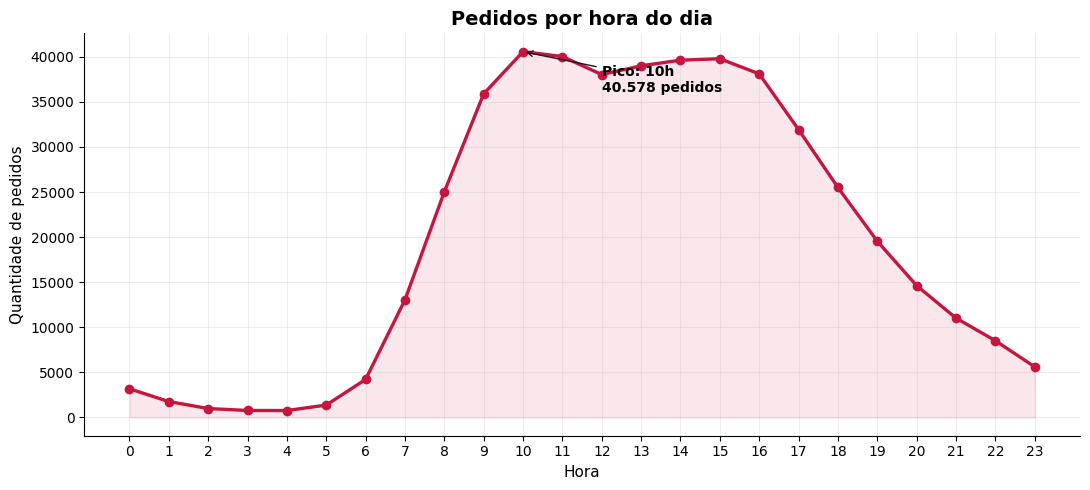

Maior volume: 10h. com 40.578 pedidos.
Menor volume: 4h. com 765 pedidos.


In [12]:
orders_by_hour = orders["order_hour_of_day"].value_counts().sort_index()
peak_hour = int(orders_by_hour.idxmax())
peak_orders = int(orders_by_hour.max())
lowest_hour = int(orders_by_hour.idxmin())
lowest_orders = int(orders_by_hour.min())

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    marker="o",
    linewidth=2.4,
    color=COLORS["primary"],
)
ax.fill_between(
    orders_by_hour.index,
    orders_by_hour.values,
    color=COLORS["primary"],
    alpha=0.10,
)
ax.annotate(
    f"Pico: {peak_hour}h\n{peak_orders:,} pedidos".replace(",", "."),
    xy=(peak_hour, peak_orders),
    xytext=(peak_hour + 2, peak_orders - 4500),
    arrowprops={"arrowstyle": "->", "color": COLORS["dark"]},
    fontweight="bold",
)
ax.set_title("Pedidos por hora do dia")
ax.set_xlabel("Hora")
ax.set_ylabel("Quantidade de pedidos")
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig(IMAGE_DIR / "orders_by_hour.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Maior volume: {peak_hour}h, com {peak_orders:,} pedidos.".replace(",", "."))
print(f"Menor volume: {lowest_hour}h, com {lowest_orders:,} pedidos.".replace(",", "."))

O volume cresce rapidamente a partir da manhã e atinge o pico às **10h**, com **40.578 pedidos**. O menor movimento ocorre às **4h**, com **765 pedidos**.

### 3.2 Pedidos por dia da semana

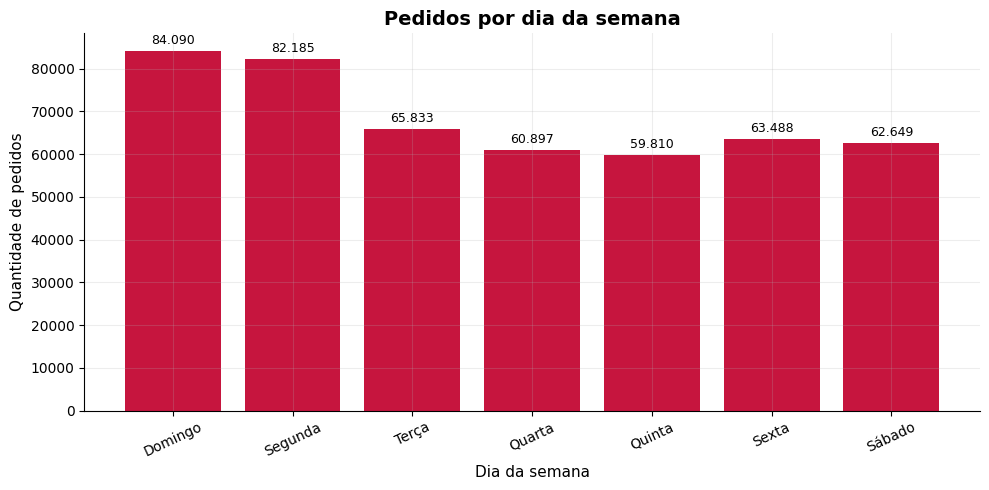

In [13]:
weekday_labels = {
    0: "Domingo",
    1: "Segunda",
    2: "Terça",
    3: "Quarta",
    4: "Quinta",
    5: "Sexta",
    6: "Sábado",
}
orders_by_weekday = orders["order_dow"].value_counts().reindex(range(7), fill_value=0)
orders_by_weekday.index = orders_by_weekday.index.map(weekday_labels)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(orders_by_weekday.index, orders_by_weekday.values, color=COLORS["primary"])
ax.bar_label(bars, labels=[f"{v:,}".replace(",", ".") for v in orders_by_weekday.values], padding=3, fontsize=9)
ax.set_title("Pedidos por dia da semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Quantidade de pedidos")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "orders_by_weekday.png", dpi=160, bbox_inches="tight")
plt.show()

Domingo apresenta o maior volume, com **84.090 pedidos**, seguido por segunda-feira, com **82.185**. Quinta-feira registra o menor total, com **59.810 pedidos**.

### 3.3 Dias desde o pedido anterior

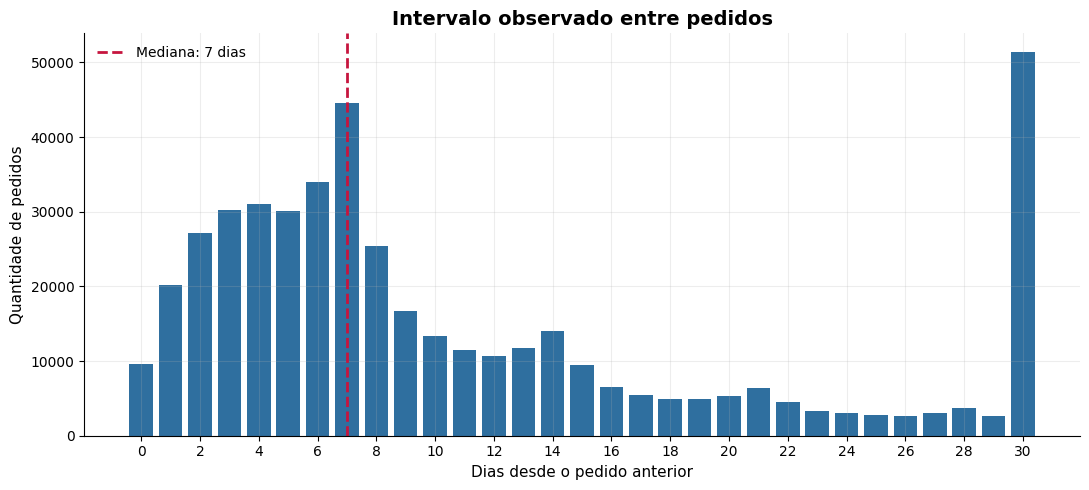

,days_since_prior_order
count,"450,135.000"
mean,11.102
std,9.190
min,0.000
25%,4.000
50%,7.000
75%,15.000
max,30.000


In [14]:
days_since_prior = orders["days_since_prior_order"].dropna()
days_distribution = days_since_prior.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(days_distribution.index, days_distribution.values, color=COLORS["secondary"])
ax.axvline(days_since_prior.median(), color=COLORS["primary"], linestyle="--", linewidth=2, label=f"Mediana: {days_since_prior.median():.0f} dias")
ax.set_title("Intervalo observado entre pedidos")
ax.set_xlabel("Dias desde o pedido anterior")
ax.set_ylabel("Quantidade de pedidos")
ax.set_xticks(range(0, 31, 2))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "days_since_prior_order.png", dpi=160, bbox_inches="tight")
plt.show()

display(days_since_prior.describe().to_frame("days_since_prior_order"))

O intervalo observado varia de **0 a 30 dias**, com média de **11,10 dias** e mediana de **7 dias**. A concentração em 7 dias é compatível com recorrência semanal na amostra, enquanto o valor 30 deve ser interpretado apenas como uma concentração observada no limite disponível do campo.

### 3.4 Comparação entre quarta-feira e sábado

Como os dois dias possuem totais diferentes, a comparação principal usa a participação percentual de cada horário dentro do respectivo dia.

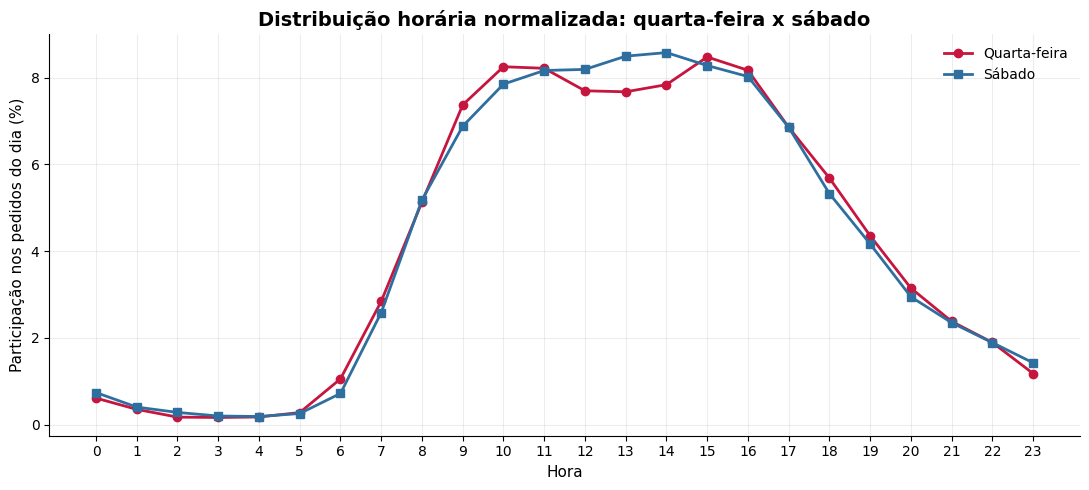

,total_orders,peak_hour,peak_share_percent
Quarta-feira,60897,15,8.478
Sábado,62649,14,8.580


In [15]:
wed_hour = orders.loc[orders["order_dow"].eq(3), "order_hour_of_day"].value_counts().reindex(range(24), fill_value=0)
sat_hour = orders.loc[orders["order_dow"].eq(6), "order_hour_of_day"].value_counts().reindex(range(24), fill_value=0)

comparison = pd.DataFrame({
    "Quarta-feira (%)": wed_hour / wed_hour.sum() * 100,
    "Sábado (%)": sat_hour / sat_hour.sum() * 100,
})

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(comparison.index, comparison["Quarta-feira (%)"], marker="o", linewidth=2, color=COLORS["primary"], label="Quarta-feira")
ax.plot(comparison.index, comparison["Sábado (%)"], marker="s", linewidth=2, color=COLORS["secondary"], label="Sábado")
ax.set_title("Distribuição horária normalizada: quarta-feira x sábado")
ax.set_xlabel("Hora")
ax.set_ylabel("Participação nos pedidos do dia (%)")
ax.set_xticks(range(24))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "wednesday_vs_saturday.png", dpi=160, bbox_inches="tight")
plt.show()

comparison_peaks = pd.DataFrame({
    "total_orders": [int(wed_hour.sum()), int(sat_hour.sum())],
    "peak_hour": [int(wed_hour.idxmax()), int(sat_hour.idxmax())],
    "peak_share_percent": [comparison["Quarta-feira (%)"].max(), comparison["Sábado (%)"].max()],
}, index=["Quarta-feira", "Sábado"])
display(comparison_peaks)

As curvas são semelhantes durante a madrugada, mas divergem no meio do dia. Quarta-feira tem maior participação relativa entre **9h e 10h**, enquanto sábado concentra mais pedidos entre **12h e 14h**. O pico ocorre às **15h na quarta-feira** e às **14h no sábado**.

### 3.5 Número de pedidos por cliente

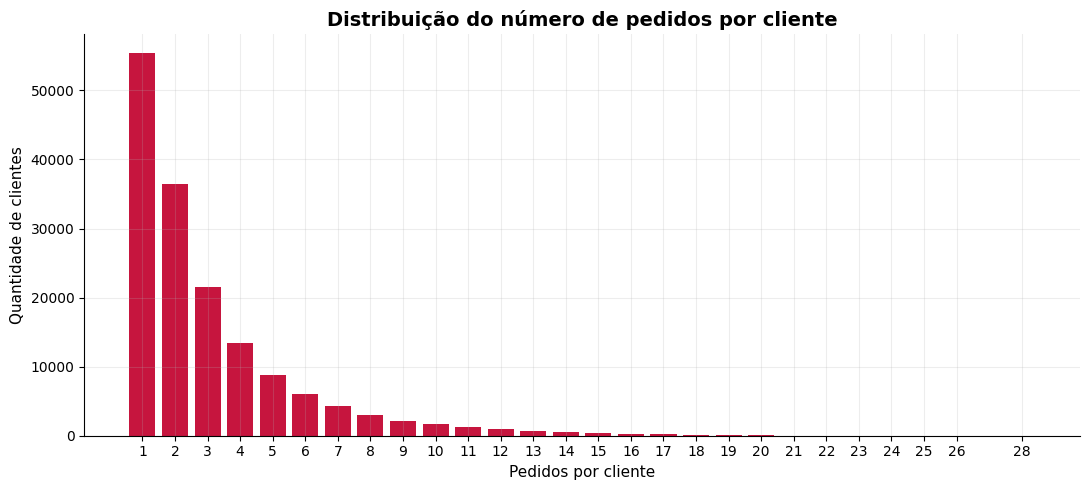

,value
customers,"157,437.000"
mean_orders,3.042
median_orders,2.000
mode_orders,1.000
maximum_orders,28.000


In [16]:
orders_per_customer = orders.groupby("user_id")["order_id"].nunique()
customer_order_distribution = orders_per_customer.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(customer_order_distribution.index, customer_order_distribution.values, color=COLORS["primary"])
ax.set_title("Distribuição do número de pedidos por cliente")
ax.set_xlabel("Pedidos por cliente")
ax.set_ylabel("Quantidade de clientes")
ax.set_xticks(customer_order_distribution.index)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "orders_per_customer.png", dpi=160, bbox_inches="tight")
plt.show()

customer_metrics = pd.Series({
    "customers": orders_per_customer.size,
    "mean_orders": orders_per_customer.mean(),
    "median_orders": orders_per_customer.median(),
    "mode_orders": orders_per_customer.mode().iloc[0],
    "maximum_orders": orders_per_customer.max(),
})
display(customer_metrics.to_frame("value"))

A distribuição é assimétrica: a maioria dos clientes realizou poucos pedidos. A mediana é de **2 pedidos por cliente**, a média é **3,04** e a moda é **1 pedido**.

### 3.6 Produtos mais comprados

,product_id,product_name,purchases
0,24852,Banana,66050
1,13176,Bag of Organic Bananas,53297
2,21137,Organic Strawberries,37039
3,21903,Organic Baby Spinach,33971
4,47209,Organic Hass Avocado,29773
5,47766,Organic Avocado,24689
6,47626,Large Lemon,21495
7,16797,Strawberries,20018
8,26209,Limes,19690
9,27845,Organic Whole Milk,19600


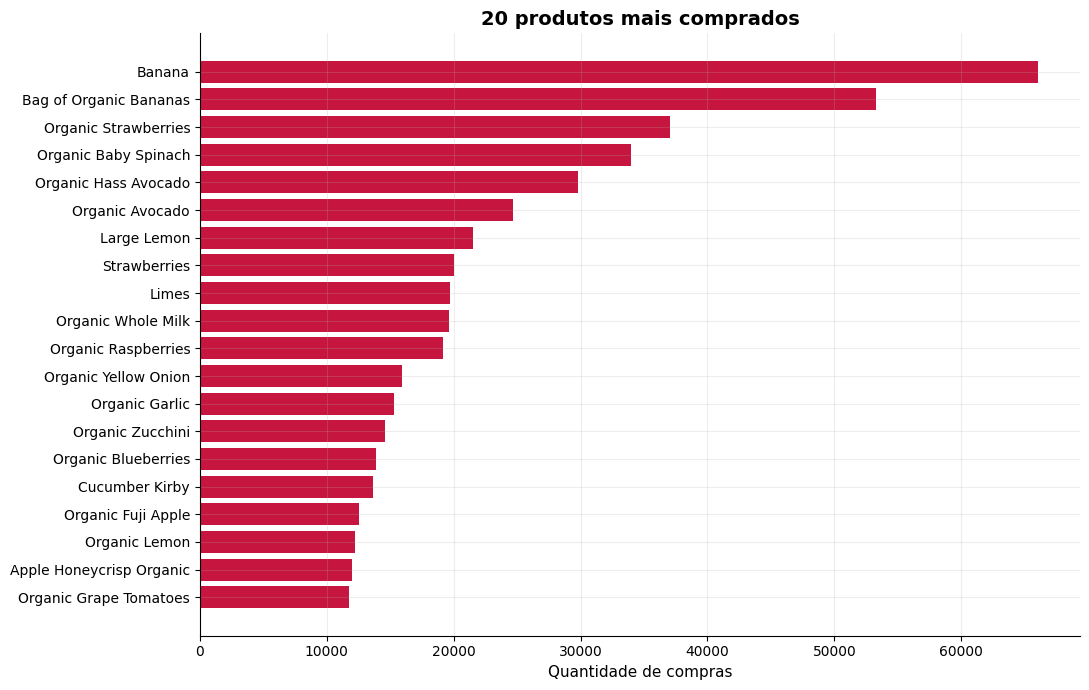

In [17]:
top_products = (
    order_products["product_id"]
    .value_counts()
    .head(20)
    .rename_axis("product_id")
    .reset_index(name="purchases")
    .merge(products[["product_id", "product_name"]], on="product_id", how="left", validate="one_to_one")
)
top_products = top_products[["product_id", "product_name", "purchases"]]
display(top_products)

plot_data = top_products.sort_values("purchases")
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_data["product_name"], plot_data["purchases"], color=COLORS["primary"])
ax.set_title("20 produtos mais comprados")
ax.set_xlabel("Quantidade de compras")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "top_products.png", dpi=160, bbox_inches="tight")
plt.show()

A **Banana** lidera com **66.050 compras**, seguida por `Bag of Organic Bananas` e `Organic Strawberries`. Frutas e itens frescos ocupam grande parte do ranking, mas a análise é descritiva e não identifica a causa dessa frequência.

## 4. Análises de carrinho e recompra

### 4.1 Quantidade de itens por pedido

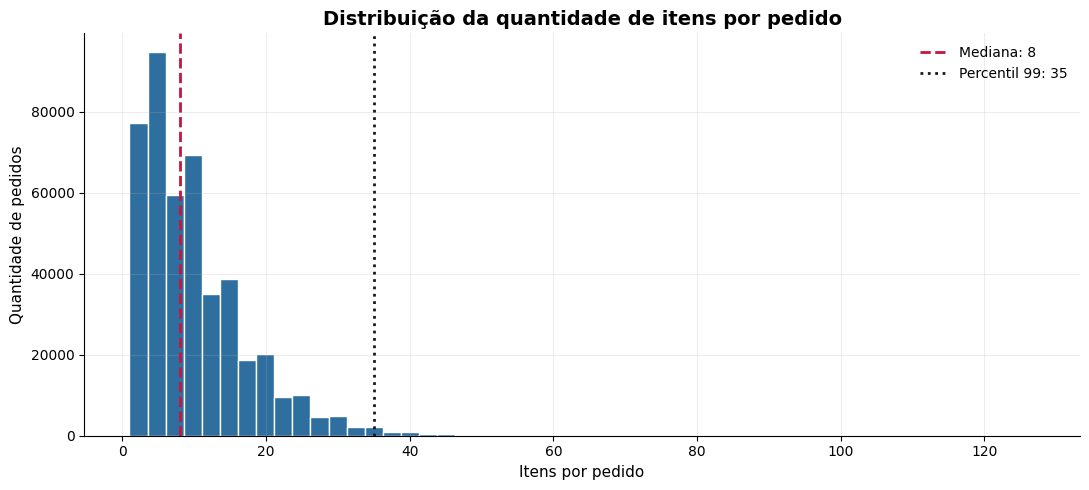

,value
orders,"450,046.000"
mean_items,10.099
median_items,8.000
mode_items,5.000
percentile_99,35.000
maximum_items,127.000
orders_above_60_items,114.000


In [18]:
items_per_order = order_products.groupby("order_id")["product_id"].size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(items_per_order, bins=50, color=COLORS["secondary"], edgecolor="white")
ax.axvline(items_per_order.median(), color=COLORS["primary"], linestyle="--", linewidth=2, label=f"Mediana: {items_per_order.median():.0f}")
ax.axvline(items_per_order.quantile(0.99), color=COLORS["dark"], linestyle=":", linewidth=2, label=f"Percentil 99: {items_per_order.quantile(0.99):.0f}")
ax.set_title("Distribuição da quantidade de itens por pedido")
ax.set_xlabel("Itens por pedido")
ax.set_ylabel("Quantidade de pedidos")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "items_per_order.png", dpi=160, bbox_inches="tight")
plt.show()

items_metrics = pd.Series({
    "orders": items_per_order.size,
    "mean_items": items_per_order.mean(),
    "median_items": items_per_order.median(),
    "mode_items": items_per_order.mode().iloc[0],
    "percentile_99": items_per_order.quantile(0.99),
    "maximum_items": items_per_order.max(),
    "orders_above_60_items": int(items_per_order.gt(60).sum()),
})
display(items_metrics.to_frame("value"))

Os pedidos possuem média de **10,10 itens**, mediana de **8** e moda de **5**. O percentil 99 é 35 itens. Apenas **114 pedidos** ultrapassam 60 itens, indicando uma cauda longa com poucos pedidos muito grandes.

### 4.2 Produtos mais recomprados

,product_id,product_name,reorders
0,24852,Banana,55763
1,13176,Bag of Organic Bananas,44450
2,21137,Organic Strawberries,28639
3,21903,Organic Baby Spinach,26233
4,47209,Organic Hass Avocado,23629
5,47766,Organic Avocado,18743
6,27845,Organic Whole Milk,16251
7,47626,Large Lemon,15044
8,27966,Organic Raspberries,14748
9,16797,Strawberries,13945


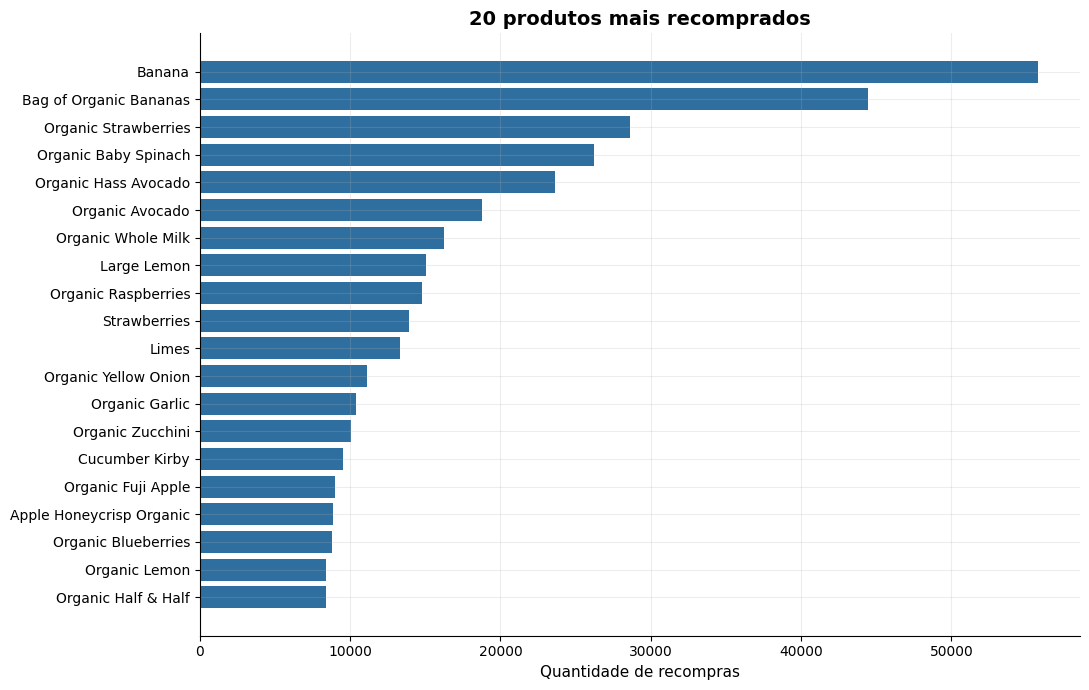

In [19]:
top_reordered = (
    order_products.loc[order_products["reordered"].eq(1), "product_id"]
    .value_counts()
    .head(20)
    .rename_axis("product_id")
    .reset_index(name="reorders")
    .merge(products[["product_id", "product_name"]], on="product_id", how="left", validate="one_to_one")
)
top_reordered = top_reordered[["product_id", "product_name", "reorders"]]
display(top_reordered)

plot_data = top_reordered.sort_values("reorders")
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_data["product_name"], plot_data["reorders"], color=COLORS["secondary"])
ax.set_title("20 produtos mais recomprados")
ax.set_xlabel("Quantidade de recompras")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "top_reordered_products.png", dpi=160, bbox_inches="tight")
plt.show()

A Banana também lidera as recompras, com **55.763 ocorrências**. O ranking é parecido com o de compras totais, mostrando que os produtos mais frequentes também aparecem repetidamente nas cestas.

### 4.3 Taxa de recompra por produto

Uma taxa de 100% pode ser enganosa quando o produto foi comprado poucas vezes. Por isso, a tabela inclui volume e o ranking principal exige pelo menos 50 compras.

In [20]:
product_reorder_stats = (
    order_products.groupby("product_id")["reordered"]
    .agg(total_purchases="size", reorders="sum", reorder_rate="mean")
    .reset_index()
    .merge(products[["product_id", "product_name"]], on="product_id", how="left", validate="one_to_one")
)

products_with_100_rate = int(product_reorder_stats["reorder_rate"].eq(1).sum())
reliable_reorder_ranking = (
    product_reorder_stats.loc[product_reorder_stats["total_purchases"].ge(50)]
    .sort_values(["reorder_rate", "total_purchases"], ascending=[False, False])
    .head(20)
    [["product_id", "product_name", "total_purchases", "reorders", "reorder_rate"]]
)

print(f"Produtos com taxa bruta de recompra de 100%: {products_with_100_rate:,}".replace(",", "."))
display(reliable_reorder_ranking)

Produtos com taxa bruta de recompra de 100%: 1.809


,product_id,product_name,total_purchases,reorders,reorder_rate
44045,48041,DanActive Vanilla Probiotic Dairy Drink,65,59,0.908
30242,32978,Lemon Lime Seltzer,66,59,0.894
36458,39782,Organic Raspberry Mate Energy Drink,65,58,0.892
15984,17469,Lo-Carb Energy Drink,63,56,0.889
22943,25000,Whole Wheat Multigrain Pop Cakes,53,47,0.887
44092,48095,Purified Water- 9.5pH+,57,50,0.877
8483,9292,Half And Half Ultra Pasteurized,397,348,0.877
2450,2677,Yerba Mate Sparkling Classic Gold,171,149,0.871
43292,47231,Ultra-Purified Water,205,178,0.868
1046,1157,Wheat Sandwich Bread,147,127,0.864


Existem **1.809 produtos com taxa bruta de 100%**, o que confirma que a taxa isolada não é suficiente. O ranking filtrado combina frequência e estabilidade, tornando a comparação mais defensável.

### 4.4 Proporção de produtos recomprados por cliente

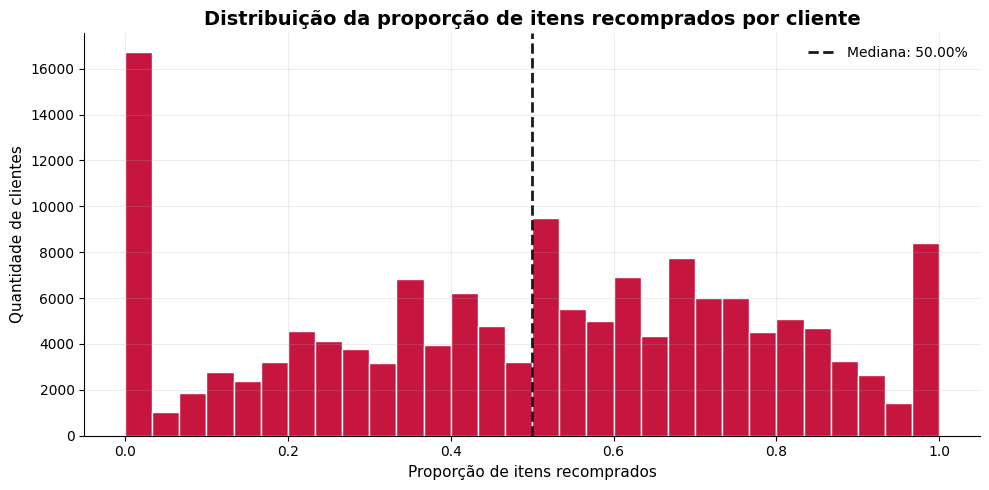

,reorder_rate
count,"149,626.000"
mean,0.495
std,0.293
min,0.000
25%,0.273
50%,0.500
75%,0.724
max,1.000


In [21]:
order_to_user = orders.set_index("order_id")["user_id"]
user_ids_for_items = order_products["order_id"].map(order_to_user)
assert user_ids_for_items.notna().all()

customer_reorder_rate = (
    pd.DataFrame({"user_id": user_ids_for_items, "reordered": order_products["reordered"]})
    .groupby("user_id")["reordered"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(customer_reorder_rate, bins=30, color=COLORS["primary"], edgecolor="white")
ax.axvline(customer_reorder_rate.median(), color=COLORS["dark"], linestyle="--", linewidth=2, label=f"Mediana: {customer_reorder_rate.median():.2%}")
ax.set_title("Distribuição da proporção de itens recomprados por cliente")
ax.set_xlabel("Proporção de itens recomprados")
ax.set_ylabel("Quantidade de clientes")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "customer_reorder_rate.png", dpi=160, bbox_inches="tight")
plt.show()

display(customer_reorder_rate.describe().to_frame("reorder_rate"))

A proporção de recompra varia bastante entre clientes. A distribuição completa é mais informativa do que exibir somente os primeiros IDs, pois mostra a diversidade de comportamentos na amostra.

### 4.5 Produtos adicionados primeiro ao carrinho

,product_id,product_name,times_added_first
0,24852,Banana,15562
1,13176,Bag of Organic Bananas,11026
2,27845,Organic Whole Milk,4363
3,21137,Organic Strawberries,3946
4,47209,Organic Hass Avocado,3390
5,21903,Organic Baby Spinach,3336
6,47766,Organic Avocado,3044
7,19660,Spring Water,2336
8,16797,Strawberries,2308
9,27966,Organic Raspberries,2024


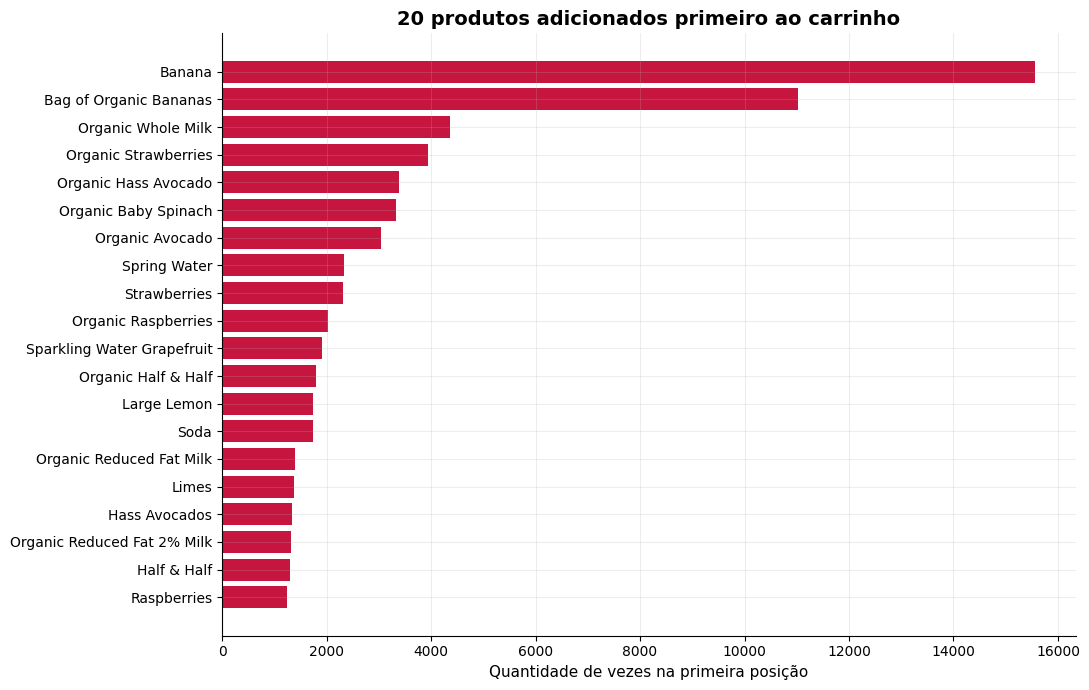

In [22]:
first_added_products = (
    order_products.loc[order_products["add_to_cart_order"].eq(1), "product_id"]
    .value_counts()
    .head(20)
    .rename_axis("product_id")
    .reset_index(name="times_added_first")
    .merge(products[["product_id", "product_name"]], on="product_id", how="left", validate="one_to_one")
)
first_added_products = first_added_products[["product_id", "product_name", "times_added_first"]]
display(first_added_products)

plot_data = first_added_products.sort_values("times_added_first")
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_data["product_name"], plot_data["times_added_first"], color=COLORS["primary"])
ax.set_title("20 produtos adicionados primeiro ao carrinho")
ax.set_xlabel("Quantidade de vezes na primeira posição")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "first_added_products.png", dpi=160, bbox_inches="tight")
plt.show()

A Banana é adicionada primeiro ao carrinho em **15.562 pedidos**, bem acima dos demais produtos. Esse resultado mostra prioridade de inclusão na cesta, mas não explica o motivo da escolha.

## 5. Conclusão geral

Após a limpeza, o conjunto contém **478.952 pedidos únicos**, **49.694 produtos** e **4.545.007 relações entre pedidos e produtos**.

Principais resultados:

- o maior volume de pedidos ocorre às **10h**, com **40.578 pedidos**;
- domingo é o dia mais movimentado, com **84.090 pedidos**;
- a mediana do intervalo entre pedidos é de **7 dias**;
- a mediana é de **2 pedidos por cliente**;
- cada pedido possui mediana de **8 itens** e média de **10,10**;
- Banana lidera compras (**66.050**), recompras (**55.763**) e itens adicionados primeiro (**15.562**);
- quarta-feira e sábado apresentam distribuições horárias semelhantes, mas sábado concentra maior participação entre 12h e 14h;
- taxas de recompra devem ser analisadas junto ao volume de compras para evitar rankings instáveis.

### Limitações

- o conjunto foi modificado e reduzido para fins educacionais;
- nomes ausentes foram preservados como `Unknown`;
- o marcador 999 identifica posições ausentes e não representa uma posição real;
- os resultados são descritivos e não demonstram causalidade nem motivação do cliente.

## 6. Competências demonstradas

- limpeza e validação de dados com pandas;
- tratamento consciente de valores ausentes e duplicados;
- agrupamentos, junções e criação de métricas;
- análise de distribuições e normalização de comparações;
- visualização com Matplotlib;
- comunicação de resultados e limitações;
- organização reproduzível para GitHub.